In [1]:
import numpy as np
import scipy.linalg
import perceval as pcvl
import math

def get_orthonormal_basis(vec):

    n = len(vec)
    vec = np.array(vec, dtype=complex)
    vec = vec / np.linalg.norm(vec)
    
    basis = np.zeros((n, n), dtype=complex)
    basis[:, 0] = vec

    null_space = scipy.linalg.null_space(vec.reshape(1, -1))
    basis[:, 1:] = null_space
    
    return basis

def generate_circuit_from_sv(name, initial_sv, controls, orientation="up", decomposition=False):

    n = initial_sv.m # Original number of spatial modes
    N = n + 1        # Expanded number of modes
    
    psi = np.zeros(n, dtype=complex)

    enlist_modes = [i for i in range(n)]
    eliminate_modes = [x for x in enlist_modes if x not in set(controls)]

    for state, amp in initial_sv:
        if state.n != 1:
            raise ValueError("This transformation requires a single-photon state.")
        
        for i in range(n):
            if state[i] == 1:
                psi[i] = amp
                break

    phi = np.copy(psi)
    for mode in eliminate_modes:
        phi[mode] = 0.0
        
    norm = np.linalg.norm(phi)
    if norm < 1e-10:
        raise ValueError("Cannot zero out all modes with non-zero amplitude.")
    phi = phi / norm
    
    psi_expanded = np.zeros(N, dtype=complex)
    phi_expanded = np.zeros(N, dtype=complex)
    
    if orientation == "up":
        # The new mode is at the end (index n)
        psi_expanded[:n] = psi 
        phi_expanded[:n] = phi / np.sqrt(2)
        phi_expanded[n] = 1.0 / np.sqrt(2)
    elif orientation == "down":
        # The new mode is at the beginning (index 0)
        psi_expanded[1:] = psi 
        phi_expanded[1:] = phi / np.sqrt(2)
        phi_expanded[0] = 1.0 / np.sqrt(2)
    else:
        raise ValueError("Orientation must be 'up' or 'down'.")
    
    V_psi = get_orthonormal_basis(psi_expanded)
    V_phi = get_orthonormal_basis(phi_expanded)
    
    U = V_phi @ V_psi.conj().T
    
    circuit = pcvl.Circuit(N, name)
    circuit.add(0, pcvl.Unitary(pcvl.Matrix(U)))
    
    target_sv = pcvl.StateVector()
    for i in range(N):
        if np.abs(phi_expanded[i]) > 1e-10:
            # Create a BasicState with 1 photon in mode i
            fock_list = [0] * N
            fock_list[i] = 1
            basic_state = pcvl.BasicState(fock_list)
            
            target_sv += pcvl.StateVector(basic_state) * complex(phi_expanded[i])

    if decomposition:
        U, _ = np.linalg.qr(U)
        
        decomposed_circuit = pcvl.Circuit.decomposition(
            pcvl.Matrix(U), 
            pcvl.BS(theta=pcvl.P('theta'), phi_tr=pcvl.P('phi')), 
            phase_shifter_fn=pcvl.PS
        )
        pcvl.pdisplay(decomposed_circuit)    

    return circuit

In [2]:
def make_SMR(modes, triggers, prefix, orientation):
    
    if modes <= 0 or not math.log2(modes).is_integer():
        raise ValueError("modes must be a positive power of 2")
    
    SMR = pcvl.Circuit(2*modes, name = prefix)

    def trigger_modes(m, triggers):
        compare = [i for i in range(modes)]
        params = [0 for i in range(modes)] # Assign pi phase only to phase shifters corresponding to trigger modes
        
        for i in range(m):
            if compare[i] in triggers:
                params[i] = np.pi
        return params
    
    def swap(index1, index2, permutation):

        a = permutation[index1]
        permutation[index1] = permutation[index2]
        permutation[index2] = a

        return permutation
    
    def generate_permutation_circuit(m):

        perm_list = []
        
        for i in range(0,int(m/2-1)):
        
            perm = [i for i in range(m)] # A list of all the mode index; example: [0,1,2,3,4,5,6,7]
            
            a = [int(m/2) - i - 1] # Here I am defining the first element of the permuting list 
            
            for j in range(1, 2*(i+1)):
                a.append(int(m/2) - i - 1 + j) # Appending to make the full permuting list
        
            a = list(zip(a[::2], a[1::2])) # We have to now pair the successive indices because they are the ones we want to swap
            
            for j in range(len(a)):
                perm = swap(a[j][0], a[j][1], perm) # We swap according to the permuting list

            perm_list.append(perm)

        return perm_list

    def pre_permute(circuit, permute_list):

        for i in range(len(permute_list)):
            #print(permute_list[i])
            circuit.add(0, pcvl.PERM(permute_list[i]))

        return circuit
    
    def generate_MZI(circuit, modes):

        n_params = modes
        params = [pcvl.Parameter(f"{prefix}_phi_{i}") for i in range(n_params)] # We define parameters for each MZI

        for i in range(modes):
            MZI_pos = 2*i # Each MZI is after 2 modes, so we define this        
            circuit.add(MZI_pos, pcvl.BS.H()).add(MZI_pos + 1, pcvl.PS(params[i])).add(MZI_pos, pcvl.BS.H())

        return circuit

    def post_permute(circuit, permute_list):

        post_permute_list = permute_list[::-1]
        
        for i in range(len(post_permute_list)):
            circuit.add(0, pcvl.PERM(post_permute_list[i]))

        return circuit

    params = trigger_modes(modes, triggers)
    perm = generate_permutation_circuit(2*modes) # m = 2*modes because ancilla too would require m modes
    circ1 = pre_permute(SMR, perm) # Adding permutations
    circ2 = generate_MZI(circ1, modes) # Adding MZIs
    circ3 = post_permute(circ2, perm) # Inverting permutations
    
    if orientation == "up":
        circuit = pcvl.Circuit(2*modes+1, prefix)
        circuit.add(0, circ3)
    elif orientation == "down":
        circuit = pcvl.Circuit(2*modes+1, prefix)
        circuit.add(1, circ3)
    
    parameters = circ3.get_parameters()
    for i, phase in enumerate(parameters):
        phase.set_value(params[i]) # Each parameter has to be independently assigned a value
    
    return circuit

In [3]:
def shift_statevector(q, shift=0, new_modes=None):
    result = pcvl.StateVector()
    for basis, amp in q:
        vec = list(basis)

        # determine output size
        if new_modes is None:
            out_size = len(vec) + shift
        else:
            out_size = new_modes

        new_vec = [0] * out_size

        for i, v in enumerate(vec):
            new_vec[i + shift] = v

        result += amp * pcvl.StateVector(new_vec)

    return result

def embed_state(q, orientation="up"):
    if orientation == "up":
        return shift_statevector(q, shift=0, new_modes=5)
    elif orientation == "down":
        return shift_statevector(q, shift=1, new_modes=5)
    else:
        raise ValueError("direction must be 'up' or 'down'")

In [4]:
q1 = (float(np.sqrt(0.5/10)) * pcvl.StateVector([1, 0, 0, 0]) + 
      float(np.sqrt(0.5/10)) * pcvl.StateVector([0, 1, 0, 0]) + 
      float(np.sqrt(3/10)) * pcvl.StateVector([0, 0, 1, 0]) + 
      float(np.sqrt(6/10)) * pcvl.StateVector([0, 0, 0, 1]))

q2 = (float(np.sqrt(1.7/9)) * pcvl.StateVector([1, 0, 0, 0]) + 
      float(np.sqrt(1.5/9)) * pcvl.StateVector([0, 1, 0, 0]) + 
      float(np.sqrt(1/9)) * pcvl.StateVector([0, 0, 1, 0]) + 
      float(np.sqrt(4.8/9)) * pcvl.StateVector([0, 0, 0, 1]))

control1 = [1,2]
control2 = [0,3]

total_state_vector = q1 * embed_state(q1, "up") * embed_state(q2, "down") * q2

print(f"Total number of spatial modes: {total_state_vector.m}")
print(f"Total number of terms in superposition: {len(total_state_vector)}")

Total number of spatial modes: 18
Total number of terms in superposition: 256


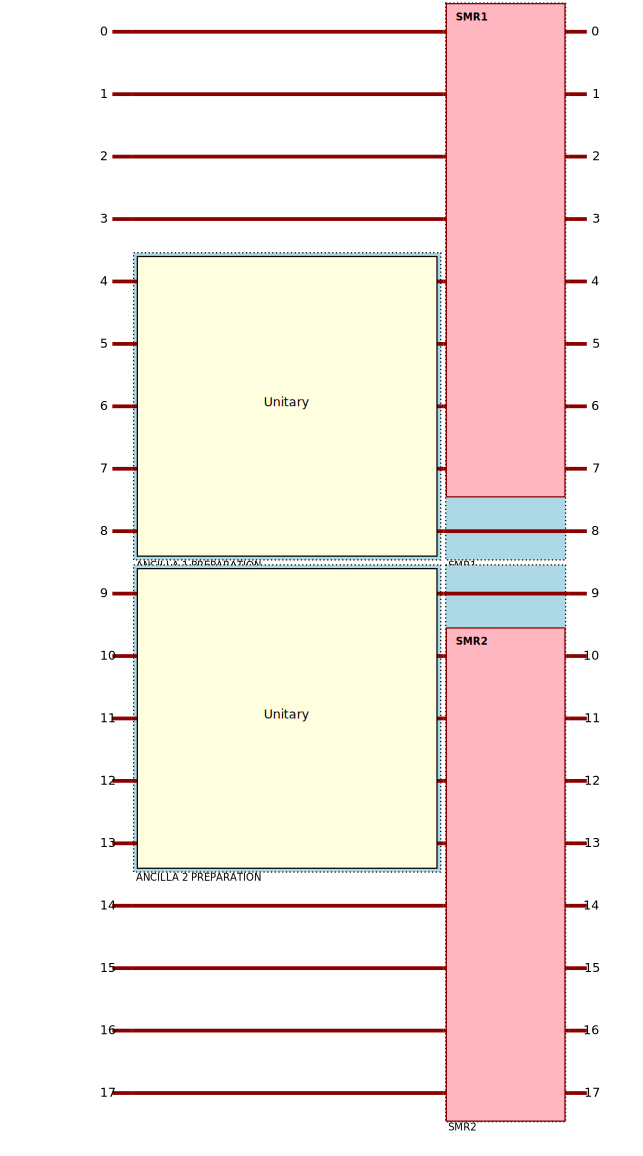

In [5]:
routing_circuit = pcvl.Circuit(18)

routing_circuit.add(4, generate_circuit_from_sv("Ancilla 1 Preparation", q1, control1, orientation="up")).add(0, make_SMR(4, control1, "SMR1", orientation="up")).add(9, generate_circuit_from_sv("Ancilla 2 Preparation", q2, control2, orientation="down")).add(9, make_SMR(4, control2, "SMR2", orientation="down"))

pcvl.pdisplay(routing_circuit, recursive = True)

In [6]:
import numpy as np
import scipy.linalg
import perceval as pcvl

def get_orthonormal_basis(vec):
    
    n = len(vec)
    vec = np.array(vec, dtype=complex)
    
    norm = np.linalg.norm(vec)
    if norm < 1e-10:
        return np.eye(n, dtype=complex)
        
    vec = vec / norm
    
    basis = np.zeros((n, n), dtype=complex)
    basis[:, 0] = vec
    
    null_space = scipy.linalg.null_space(vec.reshape(1, -1))
    basis[:, 1:] = null_space
    
    return basis

def generate_basis_rotation_circuit(name, theoretical_sv, controls, U_SMR=None, orientation="up", decomposition=False):

    n = theoretical_sv.m  # Expected to be 4 modes
    
    psi = np.zeros(n, dtype=complex)
    
    for state, amp in theoretical_sv:
        if state.n == 1:
            for i in range(n):
                if state[i] == 1:
                    psi[i] = amp
                    break

    phi = np.copy(psi)
    enlist_modes = list(range(n))
    eliminate_modes = [x for x in enlist_modes if x not in set(controls)]
    
    for mode in eliminate_modes:
        phi[mode] = 0.0
        
    norm = np.linalg.norm(phi)
    if norm < 1e-10:
        raise ValueError("No valid trigger amplitude found in the input state.")
    phi = phi / norm
    
    if U_SMR is not None:
        state_at_O = U_SMR @ phi
    else:
        state_at_O = phi

    target_state = np.zeros(n, dtype=complex)
    if orientation == "down":
        target_state[0] = 1.0  # Maps to the first local path of the 4-mode unitary
    elif orientation == "up":
        target_state[n-1] = 1.0  # Maps to the last local path of the 4-mode unitary
    else:
        raise ValueError("Orientation must be 'up' or 'down'.")
        
    V_psi = get_orthonormal_basis(state_at_O)
    V_target = get_orthonormal_basis(target_state)
    
    U = V_target @ V_psi.conj().T
    
    circuit = pcvl.Circuit(n, name)
    circuit.add(0, pcvl.Unitary(pcvl.Matrix(U)))
    
    if decomposition:
        U_decomp, _ = np.linalg.qr(U)
        decomposed_circuit = pcvl.Circuit.decomposition(
            pcvl.Matrix(U_decomp), 
            pcvl.BS(theta=pcvl.P('theta'), phi_tr=pcvl.P('phi')), 
            phase_shifter_fn=pcvl.PS
        )
        pcvl.pdisplay(decomposed_circuit)    
        
    return circuit

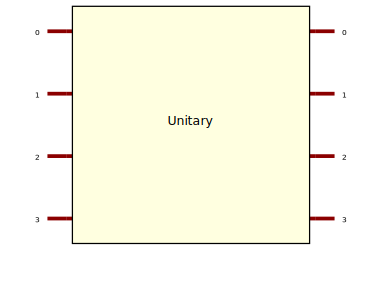

In [7]:
O1 = generate_basis_rotation_circuit("O1", q1, control1, orientation="down", decomposition=False)

pcvl.pdisplay(O1)

In [8]:
simulator = pcvl.Simulator(pcvl.SLOSBackend())
simulator.set_circuit(O1)

final_state = simulator.evolve(q1)

final_state

0.592*|1,0,0,0>-0.207*|0,0,1,0>-0.085*|0,1,0,0>+0.775*|0,0,0,1>

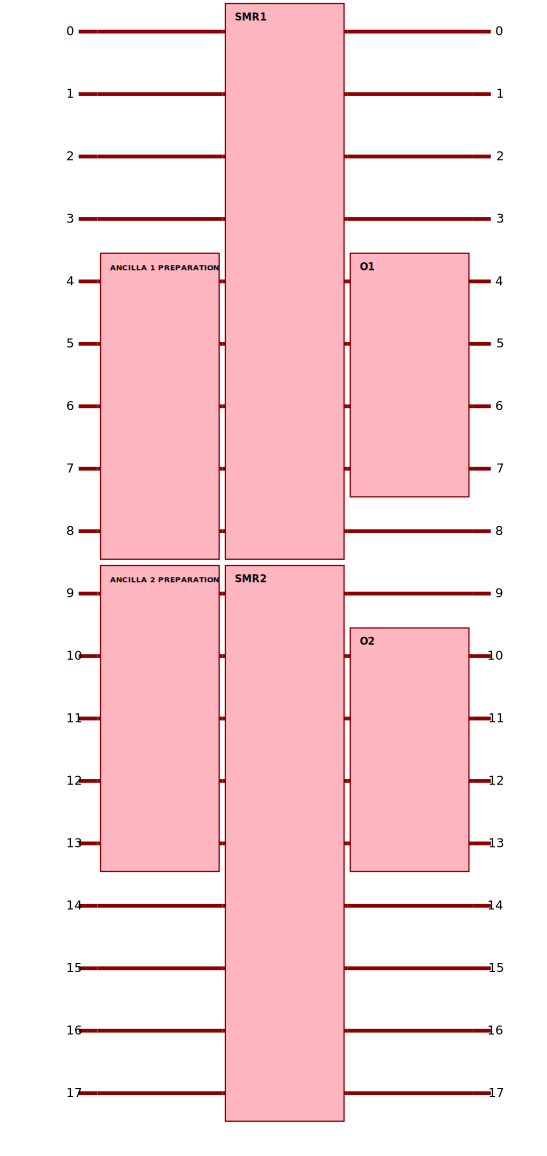

In [9]:
O_circuit = routing_circuit.add(4, generate_basis_rotation_circuit("O1", q1, control1, orientation="up", decomposition=False)).add(10, generate_basis_rotation_circuit("O2", q2, control2, orientation="down", decomposition=False))
#.add(0, pcvl.PERM([0,1,2,3,4,5,6,7,8,10,9,11,12,13,14,15,16,17]))
pcvl.pdisplay(O_circuit)

In [10]:
def Hadamard():
    circuit = pcvl.Circuit(2, "Hadamard")
    circuit.add(0, pcvl.BS.H())
    return circuit

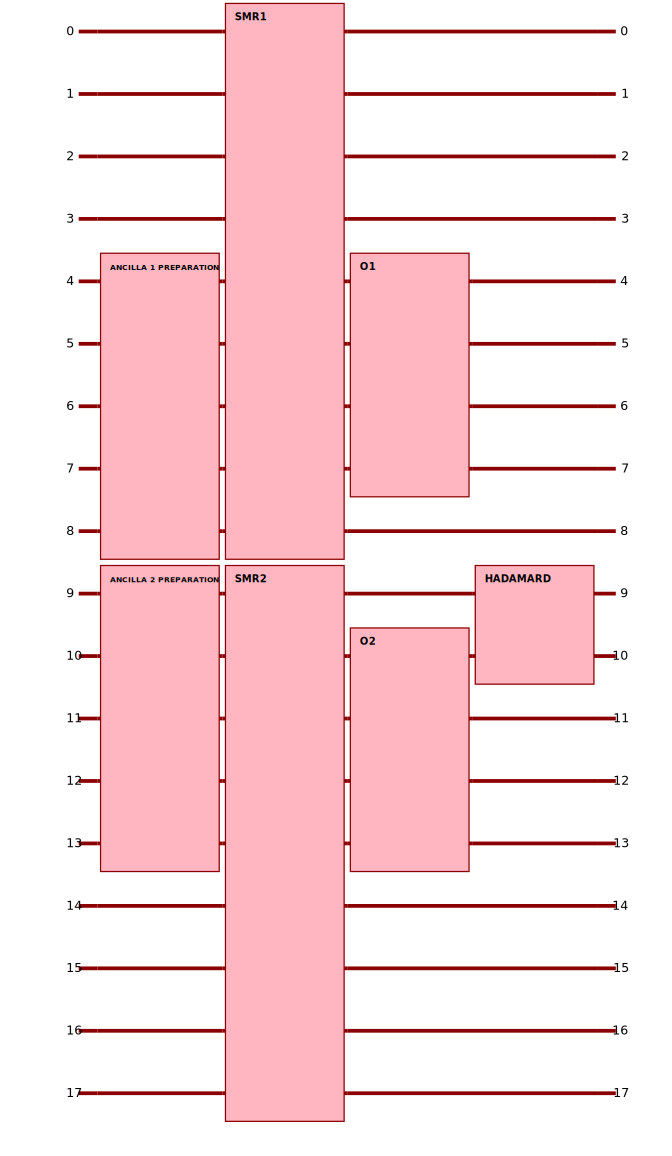

In [11]:
H_circuit = O_circuit.add(9, Hadamard())
pcvl.pdisplay(H_circuit)

In [12]:
def BSM():
    BSM = pcvl.Circuit(4, "BSM").add(0, pcvl.PERM([0,2,1,3])).add(0, pcvl.PERM([0,1,3,2])).add(0, pcvl.BS.H()).add(2, pcvl.BS.H())
    return BSM

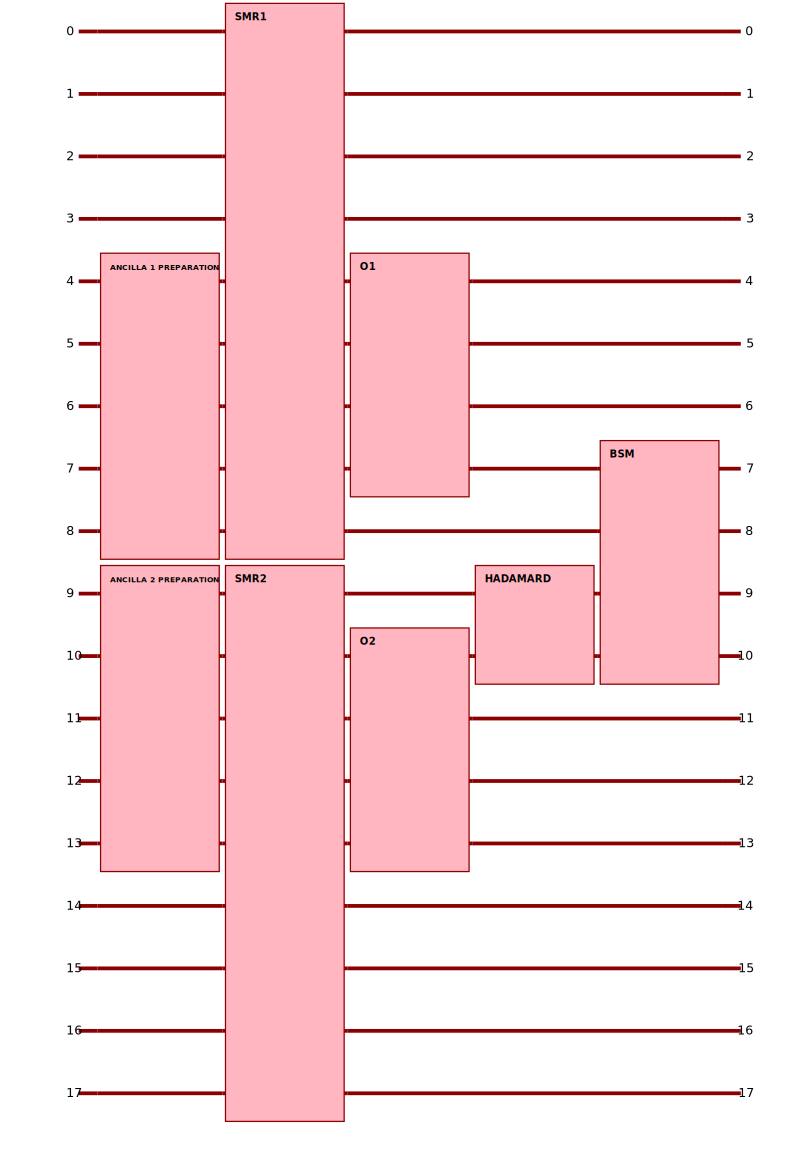

In [13]:
BSM_circuit = O_circuit.add(7, BSM())

pcvl.pdisplay(BSM_circuit)

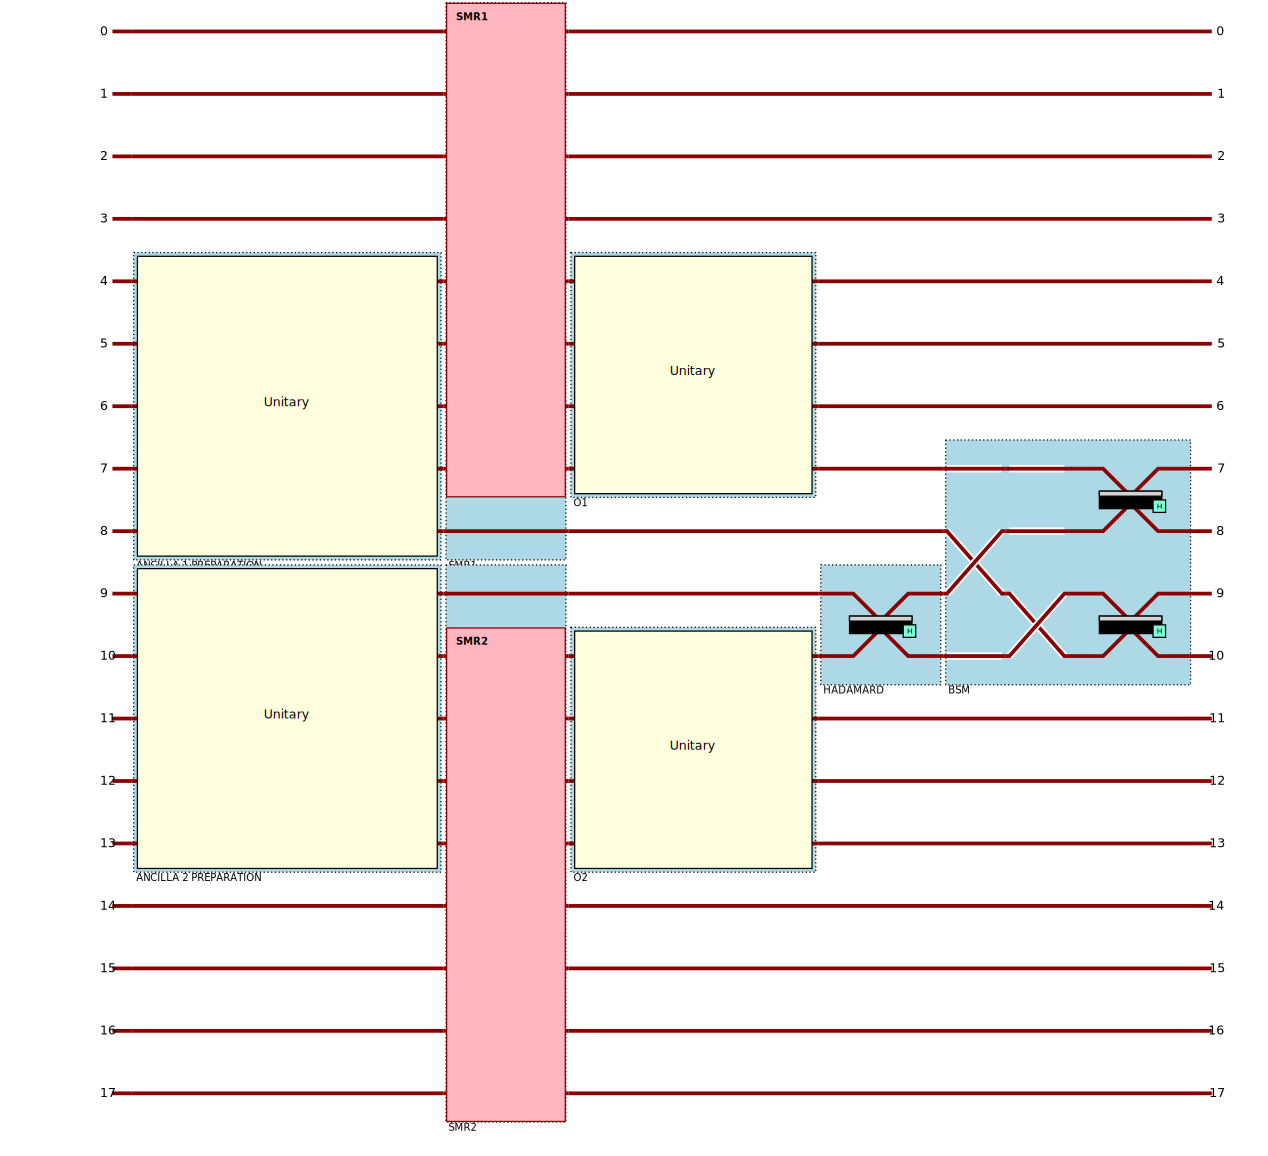

In [14]:
pcvl.pdisplay(BSM_circuit, recursive = True)

In [15]:
simulator = pcvl.Simulator(pcvl.SLOSBackend())
simulator.set_circuit(BSM_circuit)

final_state = simulator.evolve(total_state_vector)

In [16]:
final_state

0.024*|0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0>+0.06*|0,0,1,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0>-0.024*|0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0>+0.024*|0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0>+0.047*|0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,1,0>-0.108*|0,0,1,1,0,0,0,0,0,0,2,0,0,0,0,0,0,0>+0.046*|0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,1,0>+0.042*|0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,1>+0.025*|0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0>+0.024*|0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0>+0.082*|0,0,0,1,0,0,0,0,2,1,0,0,0,0,0,0,0,0>+0.06*|0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0>-0.06*|0,0,1,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0>+0.06*|0,0,1,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0>-0.058*|0,0,1,0,0,0,0,1,2,0,0,0,0,0,0,0,0,0>-0.032*|0,1,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0>+0.023*|0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1>+0.061*|0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0>-0.03*|0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0>+0.103*|0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,1>-0.024*|0,1,0,0,0,0,0,1,2,0,0,0,0,0,0,0,0,0>-0.073*|0,0,1,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0>+0.04*|0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,1

In [17]:
import perceval as pcvl

def verify_and_extract_entangled_state(final_state):
    
    filtered_state = pcvl.StateVector()

    valid_state_found = False
    
    for state, amplitude in final_state:

        if sum([state[i] for i in [4, 5, 6, 11, 12, 13]]) != 0:
            continue
            
        pattern_1 = (state[7] == 1 and state[9] == 1 and state[8] == 0 and state[10] == 0)
        pattern_2 = (state[8] == 1 and state[10] == 1 and state[7] == 0 and state[9] == 0)
        
        if pattern_1 or pattern_2:
            qudit_modes = tuple(state[i] for i in range(4)) + tuple(state[i] for i in range(14, 18))
            new_fock_state = pcvl.BasicState(qudit_modes)
            
            filtered_state += amplitude * new_fock_state
            
            valid_state_found = True
            
    if valid_state_found:
        filtered_state.normalize()
    else:
        print("Warning: No states passed the post-selection criteria.")
        
    return filtered_state

target_entangled_state = verify_and_extract_entangled_state(final_state)

print("Post-Selected Output:")
print(target_entangled_state)

Post-Selected Output:
0.258*|0,0,0,1,0,0,1,0>+0.097*|1,0,0,0,1,0,0,0>+0.183*|0,0,1,0,0,0,1,0>+0.075*|1,0,0,0,0,0,1,0>+0.566*|0,0,0,1,0,0,0,1>-0.163*|0,1,0,0,0,0,0,1>+0.224*|0,0,1,0,0,1,0,0>+0.075*|0,1,0,0,0,0,1,0>-0.097*|0,1,0,0,1,0,0,0>+0.091*|1,0,0,0,0,1,0,0>+0.337*|0,0,0,1,1,0,0,0>+0.316*|0,0,0,1,0,1,0,0>-0.238*|0,0,1,0,1,0,0,0>-0.4*|0,0,1,0,0,0,0,1>+0.163*|1,0,0,0,0,0,0,1>+0.091*|0,1,0,0,0,1,0,0>


In [18]:
print("Input: \n", q1 * q2)

Input: 
 0.238*|0,0,1,0,1,0,0,0>+0.163*|0,1,0,0,0,0,0,1>+0.183*|0,0,1,0,0,0,1,0>+0.224*|0,0,1,0,0,1,0,0>+0.4*|0,0,1,0,0,0,0,1>+0.163*|1,0,0,0,0,0,0,1>+0.097*|1,0,0,0,1,0,0,0>+0.258*|0,0,0,1,0,0,1,0>+0.075*|1,0,0,0,0,0,1,0>+0.091*|1,0,0,0,0,1,0,0>+0.097*|0,1,0,0,1,0,0,0>+0.075*|0,1,0,0,0,0,1,0>+0.091*|0,1,0,0,0,1,0,0>+0.566*|0,0,0,1,0,0,0,1>+0.337*|0,0,0,1,1,0,0,0>+0.316*|0,0,0,1,0,1,0,0>
